# Assignment 2 (NLP): PDF Question Answering Tool

**Student ID:** 1000128211

This tool answers questions from a PDF in four steps:

1. **Read the PDF.** Extract the text with pypdf.
2. **Clean the text.** Remove noise such as the $$$%%%&&&((()))
3. **Retrieve.** Split the text into small passages and use TF-IDF to find the passages most relevant to the question.
4. **Extract the answer.** The pretrained model deepset/roberta-base-squad2 picks the exact answer span from those passages.



## 1. Install and import

In [1]:
!pip install -q pypdf reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 48.3 MB/s eta 0:00:00


In [2]:
import os, re, glob, textwrap
import numpy as np
import pandas as pd
import torch
from pypdf import PdfReader
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModelForQuestionAnswering

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
QA_MODEL = "deepset/roberta-base-squad2"
print("Device:", DEVICE)

Device: cpu


## 2. Upload the PDFs

In [30]:
pdf_paths = sorted(glob.glob("/content/*.pdf"))
if not pdf_paths:                       # running in Colab -> ask for the files
    from google.colab import files
    files.upload()
    pdf_paths = sorted(glob.glob("/content/*.pdf"))

question_pdf = next((p for p in pdf_paths if "question" in os.path.basename(p).lower()), None)
doc_pdfs = [p for p in pdf_paths if p != question_pdf]
print("Documents:", doc_pdfs)
print("Questions file:", question_pdf)

Documents: ['/content/Test PDF (Easy).pdf', '/content/Test PDF (Hard).pdf']
Questions file: /content/Questions.pdf


## 3. Read and clean the PDF text

In [22]:
def read_pdf(path):
    """Return all text of a PDF as one string."""
    reader = PdfReader(path)
    return "\n".join(page.extract_text() or "" for page in reader.pages)

def clean_text(text):
    """Remove symbol noise and fix broken lines."""
    text = re.sub(r"[\$%&()_\s]*[\$%&()_]{2,}[\$%&()_\s]*\.?", " ", text)  # noise blocks like (_$$$%%%&&&)))(((_.
    text = text.replace("\u2019", "'")
    text = re.sub(r"\s+", " ", text)                                         # join lines
    text = re.sub(r"\s+([.,;:!?])", r"\1", text)                            # no space before punctuation
    return text.strip()

documents = {os.path.basename(p): clean_text(read_pdf(p)) for p in doc_pdfs}

# show what cleaning did on the hard PDF
for name in documents:
    if "hard" in name.lower():
        raw = re.sub(r"\s+", " ", read_pdf(name))
        print("RAW    :", raw[:300], "...\n")
        print("CLEANED:", documents[name][:300], "...")

RAW    : Bangladesh(_$$$$$$$$$$$$$$$$$$%%%%%%%%%%%%%%$$$$$$$$&&&&&&&&&&&&&& &&&&&&&())))))))))(((((((((((((((_$$$$$$$$$$$$$$$$$$%%%%%%%%%%%%%%$$$$$$$$&& &&&&&&&&&&&&&&&&&&&())))))))))(((((((((((((((_$$$$$$$$$$$$$$$$$$%%%%%%%%%%%% %%$$$$$$$$&&&&&&&&&&&&&&&&&&&&&())))))))))(((((((((((((((_$$$$$$$$$$$$$$$$$$%%% ...

CLEANED: Bangladesh is a beautiful country in South Asia, known for its rich cultural heritage, fertile land, and vast river systems. The capital city of Bangladesh is Dhaka. Dhaka is not only the political center but also the economic and cultural heart of the nation. It is one of the most densely populated ...


## 4. Split into passages and build the TF-IDF retriever

In [23]:
def make_passages(text, size=3):
    """Sliding windows of `size` sentences (step 1) so an answer is never cut off."""
    sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", text) if len(s.strip()) > 3]
    if len(sents) <= size:
        return [" ".join(sents)]
    return [" ".join(sents[i:i + size]) for i in range(len(sents) - size + 1)]

class Retriever:
    def __init__(self, text):
        self.passages = make_passages(text)
        self.vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), sublinear_tf=True)
        self.matrix = self.vectorizer.fit_transform(self.passages)

    def search(self, question, top_k=3):
        scores = (self.matrix @ self.vectorizer.transform([question]).T).toarray().ravel()
        best = np.argsort(-scores)[:top_k]
        return [(self.passages[i], float(scores[i])) for i in best]

retrievers = {name: Retriever(text) for name, text in documents.items()}
for name, r in retrievers.items():
    print(f"{name}: {len(r.passages)} passages")

Test PDF (Easy).pdf: 23 passages
Test PDF (Hard).pdf: 21 passages


## 5. Load the QA model (reader)

In [24]:
tokenizer = AutoTokenizer.from_pretrained(QA_MODEL)
model = AutoModelForQuestionAnswering.from_pretrained(QA_MODEL).to(DEVICE).eval()

def extract_answer(question, context, max_answer_tokens=30):
    """Return (answer_text, confidence) - the best span of `context` answering `question`."""
    enc = tokenizer(question, context, truncation="only_second", max_length=384,
                    return_offsets_mapping=True, return_tensors="pt")
    offsets = enc.pop("offset_mapping")[0]
    is_context = torch.tensor([s == 1 for s in enc.sequence_ids(0)])
    with torch.no_grad():
        out = model(**{k: v.to(DEVICE) for k, v in enc.items()})
    start_p = torch.softmax(out.start_logits[0].cpu().masked_fill(~is_context, -1e4), dim=-1)
    end_p   = torch.softmax(out.end_logits[0].cpu().masked_fill(~is_context, -1e4), dim=-1)

    # best (start, end) pair with start <= end and a reasonable length
    scores = torch.triu(start_p[:, None] * end_p[None, :])
    scores = torch.tril(scores, diagonal=max_answer_tokens - 1)
    s, e = divmod(int(scores.argmax()), scores.shape[1])
    answer = context[int(offsets[s][0]):int(offsets[e][1])]
    return answer.strip(" .,"), float(scores[s, e])

print(extract_answer("What is the capital of France?", "Paris is the capital and largest city of France."))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

('Paris', 0.9215258955955505)


## 6. The question answering tool

In [25]:
def answer_question(question, doc_name, top_k=5):
    """Retrieve the top passages, run the reader on each, keep the most confident answer."""
    best = {"answer": "Not found", "confidence": 0.0, "evidence": ""}
    for passage, _ in retrievers[doc_name].search(question, top_k):
        answer, conf = extract_answer(question, passage)
        if answer and conf > best["confidence"]:
            best = {"answer": answer, "confidence": round(conf, 3), "evidence": passage}
    return best

def ask(question, doc_name=None):
    """Ask a question about one PDF (default: the first one)."""
    doc_name = doc_name or list(documents)[0]
    r = answer_question(question, doc_name)
    print(f"Q: {question}\nA: {r['answer']}   (confidence {r['confidence']}, from {doc_name})")
    return r

## 7. Load the questions from `Questions.pdf`

In [26]:
def load_questions(path):
    text = re.sub(r"\s+", " ", read_pdf(path))
    text = re.sub(r"^\s*Questions:\s*", "", text, flags=re.I)
    text = re.sub(r"\b\d+\.\s*", "", text)                  # drop numbering "1. "
    return [q.strip() + "?" for q in text.split("?") if q.strip()]   # one line may hold two questions

if question_pdf:
    questions = load_questions(question_pdf)
else:
    questions = ["What is the capital city of Bangladesh?"]
for i, q in enumerate(questions, 1):
    print(i, q)

1 What is the capital city of Bangladesh?
2 Which river is considered the lifeline of Bangladesh?
3 In which year did Bangladesh gain independence?
4 What is the official language of Bangladesh?
5 What is the name of the world’s largest mangrove forest located in Bangladesh?
6 Which currency is used in Bangladesh?
7 What is the national animal of Bangladesh?


## 8. Answer every question from both PDFs

In [27]:
rows = []
for q in questions:
    row = {"Question": q}
    for name in documents:
        label = name.replace(".pdf", "")
        r = answer_question(q, name)
        row[f"Answer ({label})"] = r["answer"]
        row[f"Conf. ({label})"] = r["confidence"]
    rows.append(row)

results = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 60)
results

,Question,Answer (Test PDF (Easy)),Conf. (Test PDF (Easy)),Answer (Test PDF (Hard)),Conf. (Test PDF (Hard))
0,What is the capital city of Bangladesh?,Dhaka,0.962,Dhaka,0.962
1,Which river is considered the lifeline of Bangladesh?,Padma River,0.838,Padma River,0.838
2,In which year did Bangladesh gain independence?,1971,0.995,1971,0.995
3,What is the official language of Bangladesh?,Bengali,0.979,Bengali,0.979
4,What is the name of the world’s largest mangrove forest ...,Sundarbans,0.806,Sundarbans,0.806
5,Which currency is used in Bangladesh?,Bangladeshi Taka,0.857,Bangladeshi Taka,0.851
6,What is the national animal of Bangladesh?,Royal Bengal Tiger,0.825,Royal Bengal Tiger,0.825


## 9. Ask your own question

In [28]:
hard_docs = [n for n in documents if "Hard" in n]
easy_docs = [n for n in documents if "Easy" in n]

hard = hard_docs[0] if hard_docs else list(documents.keys())[0]
easy = easy_docs[0] if easy_docs else list(documents.keys())[0]

ask("What is the national animal of Bangladesh?", hard)
ask("Which forest is a UNESCO World Heritage Site?", easy)

Q: What is the national animal of Bangladesh?
A: Royal Bengal Tiger   (confidence 0.825, from Test PDF (Hard).pdf)
Q: Which forest is a UNESCO World Heritage Site?
A: Sundarbans   (confidence 0.553, from Test PDF (Easy).pdf)


{'answer': 'Sundarbans',
 'confidence': 0.553,
 'evidence': 'The importance of the language is highlighted by International Mother Language Day, which originated from the language movement in Bangladesh. Bangladesh is also famous for the Sundarbans, the largest mangrove forest in the world. This forest is a UNESCO World Heritage Site and is known for its rich biodiversity.'}

## 10. Save the output as an image (`qa_output.png`)

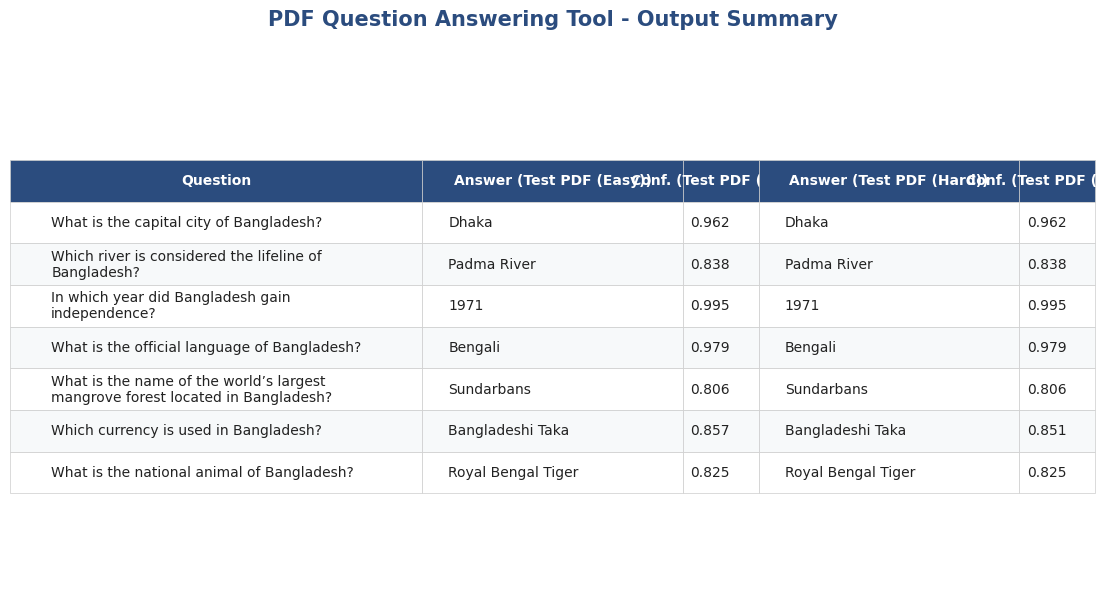

In [29]:
import matplotlib.pyplot as plt
import textwrap

table = results.copy()
table["Question"] = table["Question"].apply(lambda s: textwrap.fill(s, 45))
for c in table.columns:
    if c.startswith("Answer"):
        table[c] = table[c].apply(lambda s: textwrap.fill(str(s), 28))

# Dynamic figure sizing
fig, ax = plt.subplots(figsize=(14, 1.5 + 0.8 * len(table)))
ax.axis("off")

widths = [0.38] + [0.24 if c.startswith("Answer") else 0.07 for c in table.columns[1:]]
tbl = ax.table(cellText=table.values, colLabels=table.columns, loc="center",
               cellLoc="left", colWidths=widths)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.5)

# Style cells professionally
for (r, c), cell in tbl.get_celld().items():
    cell.set_linewidth(0.5)
    cell.set_edgecolor('#cccccc')
    if r == 0:
        cell.set_facecolor("#2b4c7e")
        cell.set_text_props(color="white", weight="bold")
    else:
        # Alternating row colors for readability
        facecolor = "#f7f9fa" if r % 2 == 0 else "#ffffff"
        cell.set_facecolor(facecolor)
        cell.set_text_props(color="#222222")

ax.set_title("PDF Question Answering Tool - Output Summary", fontsize=15, weight="bold", pad=20, color="#2b4c7e")
plt.savefig("qa_output.png", dpi=200, bbox_inches="tight")
plt.show()